In [ ]:
import json
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import os

In [ ]:
def load_json_file(json_file):
    log_dict = {}
    with open(json_file) as log_file:
        for line in log_file:
            log = json.loads(line.strip())
            # the final step in json file is 0.
            if 'step' in log and log['step'] != 0:
                step = log['step']
                prev_step = step
            else:
                step = prev_step
            if step not in log_dict:
                log_dict[step] = defaultdict(list)
            for k, v in log.items():
                log_dict[step][k].append(v)
    return log_dict

def build_plot_index_list(log_dict, metric):
    epochs = list(log_dict.keys())
    plot_epochs = []
    plot_iters = []
    plot_values = []
    for epoch in epochs:
        epoch_logs = log_dict[epoch]
        if metric not in epoch_logs.keys():
            continue
        if metric in ['mIoU', 'mAcc', 'aAcc']:
            plot_epochs.append(epoch)
            plot_values.append(epoch_logs[metric][0])
        else:
            for idx in range(len(epoch_logs[metric])):
                plot_iters.append(epoch_logs['step'][idx])
                plot_values.append(epoch_logs[metric][idx])
    if metric in ['mIoU', 'mAcc', 'aAcc']:
        return plot_epochs, plot_values
    else:
        return plot_iters, plot_values

def plot_model_performance(model_results, row, col, 
                           figsize=(12, 9), tick_label_size=16, 
                           line_width=1, marker_size=5, 
                           miou_style={"color": "#b2182b", "linestyle": "-", "marker": "o", "markerfacecolor": "#b2182b"},
                           macc_style={"color": "#2166ac", "linestyle": "-", "marker": "s", "markerfacecolor": "#2166ac"},
                           ylim=(75, 100), xlim=(0, 20000), save_path=None, dpi=600):
    """
    Plots model performance (mIoU & mAcc) over iterations in a row x col grid.

    Args:
        model_results (dict): Dictionary with model names as keys. Each value is a list containing:
                              [iterations, mIoU values, mAcc values].
        row (int): Number of rows in the grid.
        col (int): Number of columns in the grid.
        figsize (tuple): Figure size (width, height).
        tick_label_size (int): Font size for tick labels.
        line_width (float): Line width for plots.
        marker_size (float): Marker size for points.
        miou_style (dict): Line & marker style for mIoU.
        macc_style (dict): Line & marker style for mAcc.
        ylim (tuple): y-axis limits (default: (75, 100)).
        xlim (tuple): x-axis limits (default: (0, 20000)).
    """
    fig, axes = plt.subplots(row, col, figsize=figsize, dpi=300)
    axes = np.array(axes).reshape(row, col)  # Ensure correct grid shape

    model_list = list(model_results.keys())
    num_models = len(model_list)

    for idx, ax in enumerate(axes.flat):
        if idx >= num_models:
            ax.axis("off")  # Hide unused subplots
            continue
        
        model_name = model_list[idx]
        iterations, miou_values, macc_values = model_results[model_name]

        # Plot mIoU
        ax.plot(iterations, miou_values, label="mIoU",
                color=miou_style["color"], linestyle=miou_style["linestyle"],
                marker=miou_style["marker"], markerfacecolor=miou_style["markerfacecolor"],
                markersize=marker_size, linewidth=line_width)

        # Plot mAcc
        ax.plot(iterations, macc_values, label="mAcc",
                color=macc_style["color"], linestyle=macc_style["linestyle"],
                marker=macc_style["marker"], markerfacecolor=macc_style["markerfacecolor"],
                markersize=marker_size, linewidth=line_width)

        ax.set_ylim(ylim)  # Ensure consistent y-axis range
        ax.set_xlim(xlim)  # Ensure consistent x-axis range

        # **Show y-ticks only for the leftmost column with 80, 90, 100**
        if idx % col == 0:
            ax.set_yticks([80, 90, 100])  # Show only these three y-ticks
            ax.tick_params(axis="y", labelsize=tick_label_size)
        else:
            ax.set_yticks([])  # Hide y-ticks for other columns
        
        # **Show x-ticks only for the bottom row**
        if idx >= (row - 1) * col:
            ax.set_xticks(np.linspace(xlim[0], xlim[1], 3))  # Show at most 3 x-ticks
            ax.tick_params(axis="x", labelsize=tick_label_size)
            ax.ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
        else:
            ax.set_xticks([])

        # **Model Name Above X-axis**
        ax.text(0.5, 0.14, model_name, ha='center', va='top', fontsize=16, transform=ax.transAxes)
        ax.legend(loc="center right", fontsize=13)

    # Add "Percentage (%)" label on the left center
    fig.text(0, 0.5, "Percentage (%)", va='center', ha='center', fontsize=16, rotation=90)

    # Add "Iterations" label at the bottom center
    fig.text(0.5, 0, "Iterations", va='center', ha='center', fontsize=16)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    plt.show()


def get_all_subfolders(folder_path):
    subfolders = []
    for root, dirs, files in os.walk(folder_path):
        for dir_name in dirs:
            subfolders.append(os.path.join(root, dir_name))
    return subfolders

In [12]:
json_files =["/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/AnnBenchmark/20250224_191757/vis_data/20250224_191757.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/CCNetBenchmark/20250224_213436/vis_data/20250224_213436.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/DaNetBenchmark/20250224_234448/vis_data/20250224_234448.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/Deeplabv3Benchmark/20250225_015826/vis_data/20250225_015826.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/ENCNetBenchmark/20250225_043552/vis_data/20250225_043552.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/FCNBenchmark/20250225_063420/vis_data/20250225_063420.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/OcrNetBenchmark/20250225_130839/vis_data/20250225_130839.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/PsaNetBenchmark/20250225_083424/vis_data/20250225_083424.json",
             "/home/weiwang/ResearchProjects/mmsegmentation/my_model_res/PspNetBenchmark/20250225_105208/vis_data/20250225_105208.json"]

In [33]:
res_dict = {}
model_list = ["ANN", "CCNet", "DANet", "Deeplabv3", "ENCNet", "FCN", "OCRNet", "PSANet", "PSPNet"]
for i in range(len(json_files)):
    j_f = json_files[i]
    log_dict = load_json_file(j_f)
    plot_x, plot_y1 = build_plot_index_list(log_dict, 'mIoU')
    plot_x, plot_y2 = build_plot_index_list(log_dict, 'mAcc')
    res_dict[model_list[i]] = [plot_x, plot_y1, plot_y2]
    

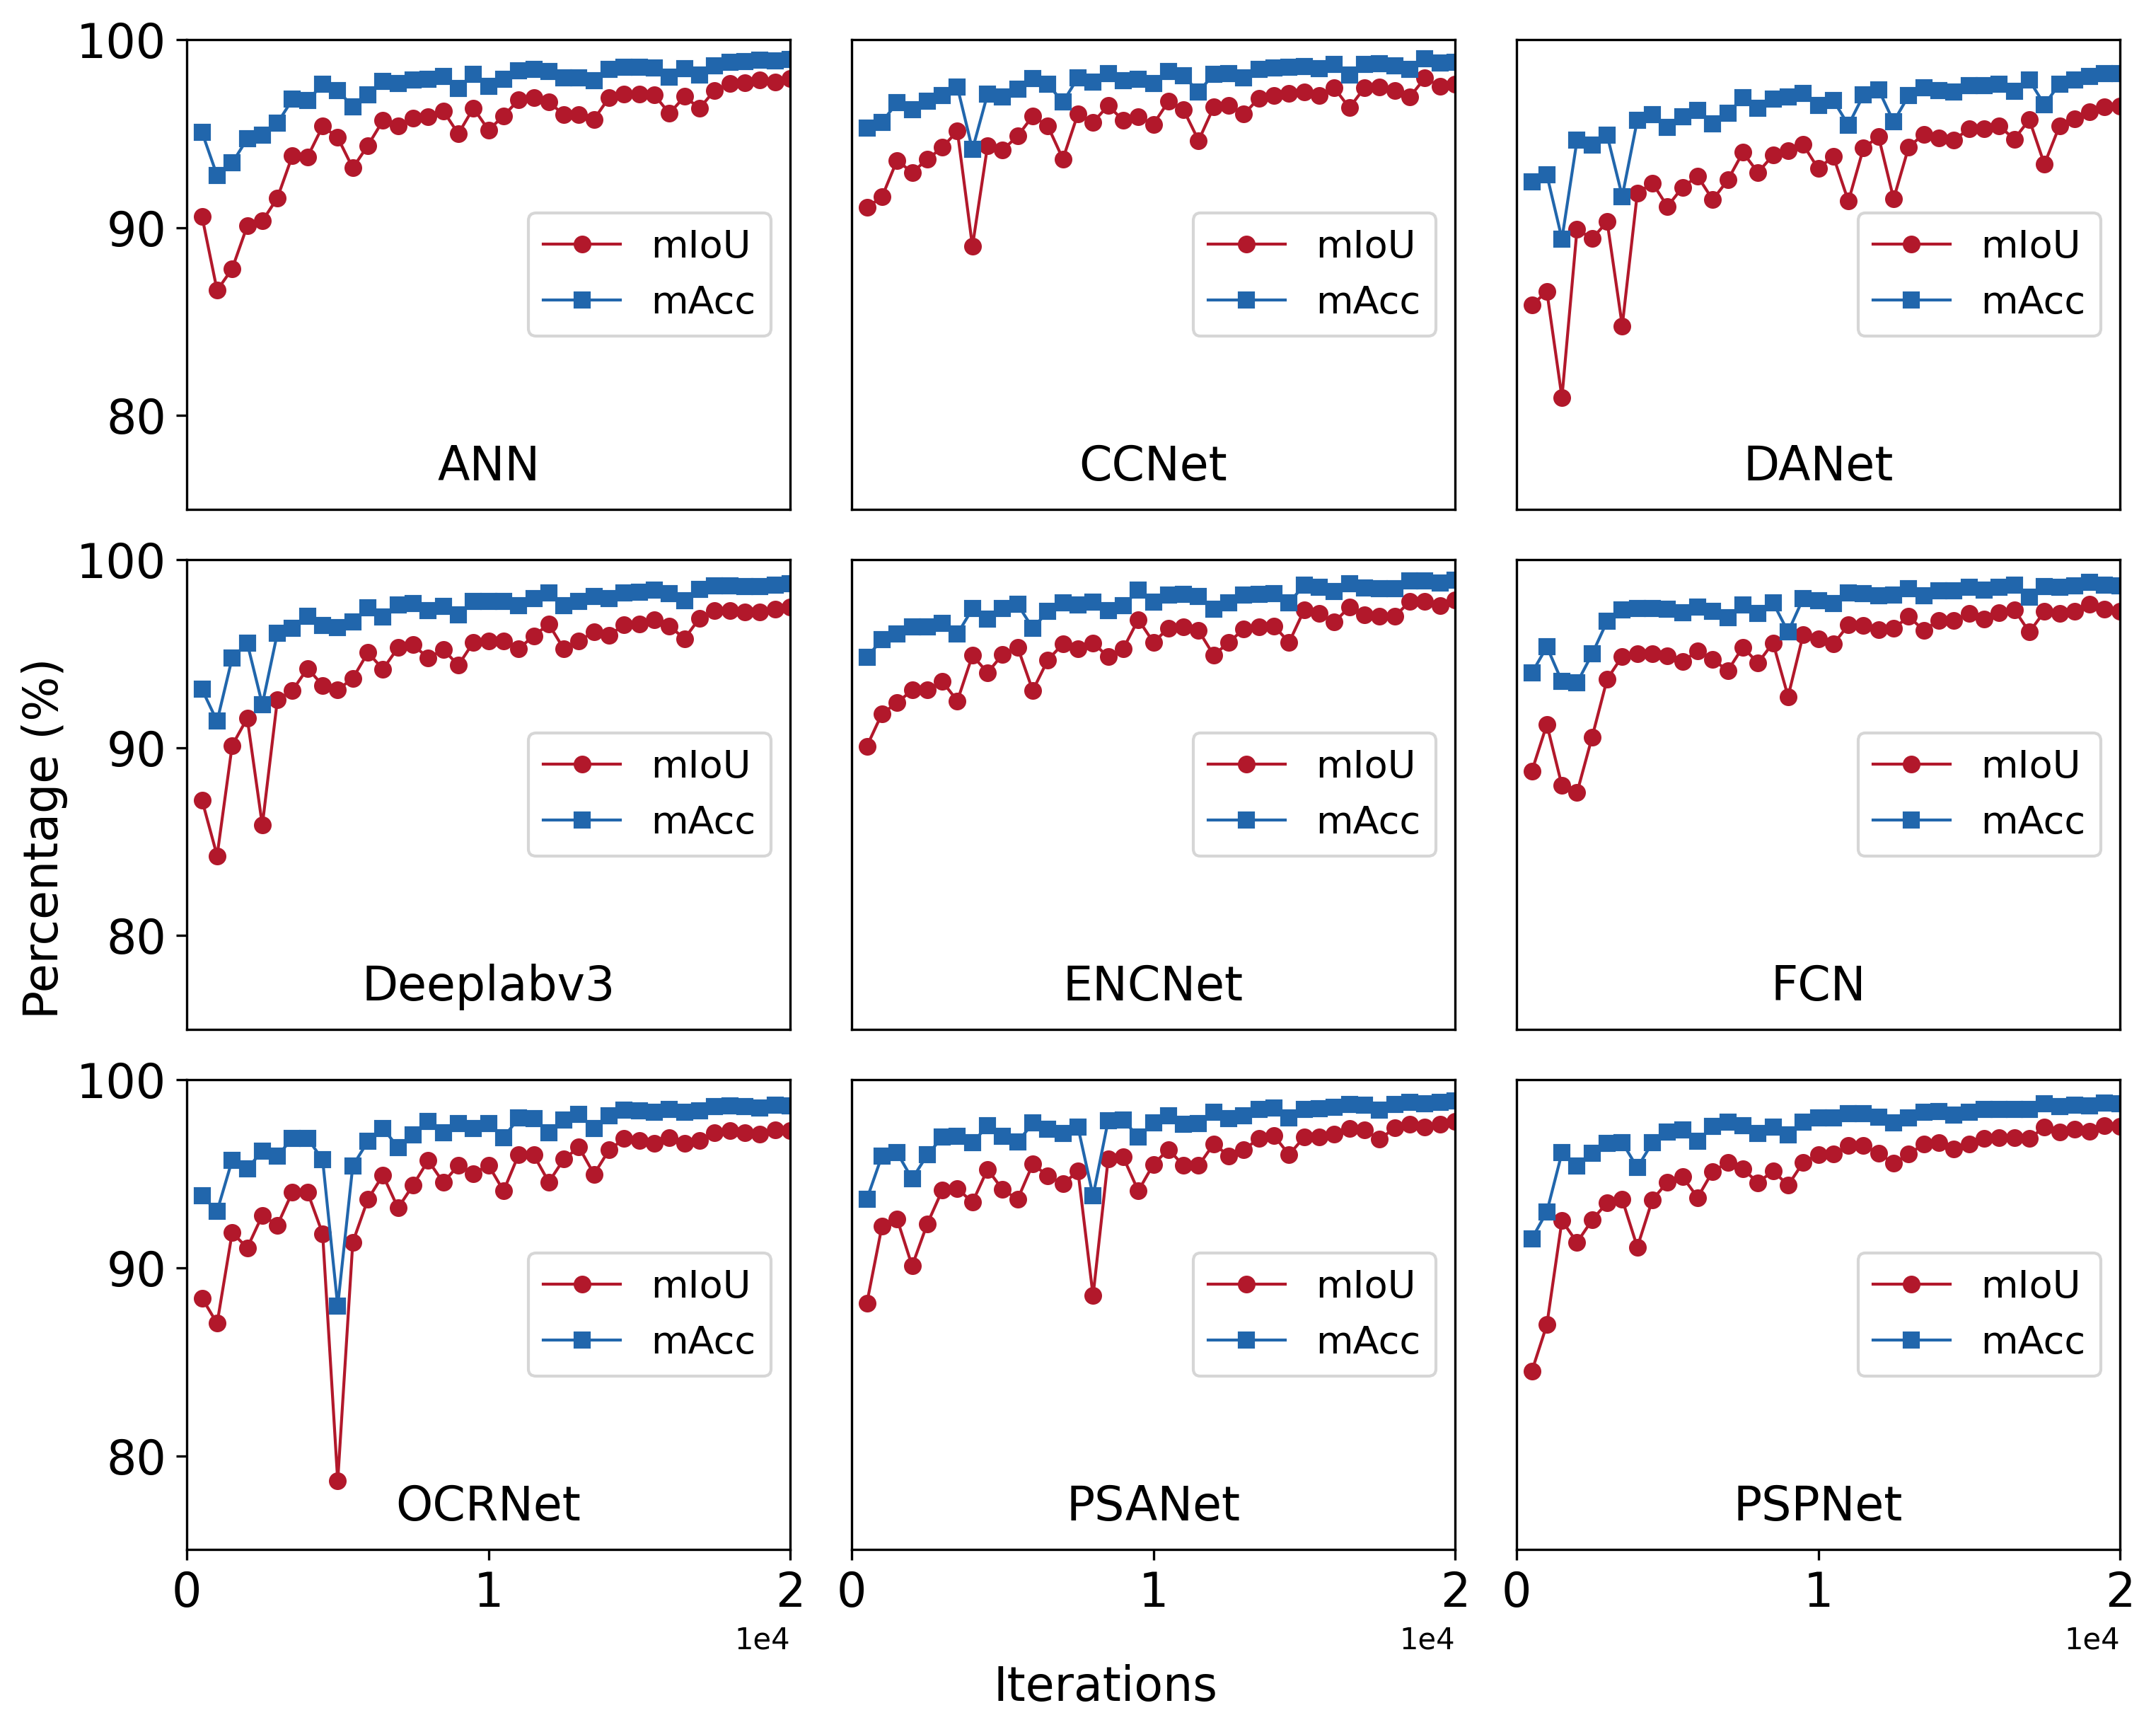

In [71]:
plot_model_performance(res_dict, row=3, col=3, figsize=(10, 8), save_path = '/home/weiwang/ResearchProjects/mmsegmentation/BenchPlots/performance.jpg')